**Import Libraries and Setup**

In [7]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    LSTM,
    GRU
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

BASE_PATH = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "processed").is_dir()
    ),
    Path.cwd()
)
PROCESSED_PATH = BASE_PATH / "processed"

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

**LOAD DATA FOR MODELS**

In [8]:
X_train = np.load(
    os.path.join(
        PROCESSED_PATH,
        "X_train_tabular.npy"
    )
)

X_val = np.load(
    os.path.join(
        PROCESSED_PATH,
        "X_val_tabular.npy"
    )
)

X_test = np.load(
    os.path.join(
        PROCESSED_PATH,
        "X_test_tabular.npy"
    )
)

y_train = np.load(
    os.path.join(
        PROCESSED_PATH,
        "y_train.npy"
    )

)

In [9]:
y_train = np.load(
    os.path.join(
        PROCESSED_PATH,
        "y_train_tabular.npy"
    )
)

y_val = np.load(
    os.path.join(
        PROCESSED_PATH,
        "y_val_tabular.npy"
    )
)

y_test = np.load(
    os.path.join(
        PROCESSED_PATH,
        "y_test_tabular.npy"
    )
)

**Load**

In [10]:
X_train = np.load(
    os.path.join(
        PROCESSED_PATH,
        "X_train_tabular.npy"
    )
)

X_val = np.load(
    os.path.join(
        PROCESSED_PATH,
        "X_val_tabular.npy"
    )
)

X_test = np.load(
    os.path.join(
        PROCESSED_PATH,
        "X_test_tabular.npy"
    )
)

y_train = np.load(
    os.path.join(
        PROCESSED_PATH,
        "y_train_tabular.npy"
    )
)

y_val = np.load(
    os.path.join(
        PROCESSED_PATH,
        "y_val_tabular.npy"
    )
)

y_test = np.load(
    os.path.join(
        PROCESSED_PATH,
        "y_test_tabular.npy"
    )
)

**Load class weights**

In [11]:
with open(
    os.path.join(
        PROCESSED_PATH,
        "class_weights.json"
    ),
    "r"
) as f:

    class_weights = json.load(f)

class_weights = {
    int(k): float(v)
    for k, v in class_weights.items()
}

print(class_weights)

{0: 0.518225536310664, 1: 14.21701747145412}


**Build MLP**

In [12]:
model = Sequential([

    Input(
        shape=(
            X_train.shape[1],
        )
    ),

    Dense(
        128,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,201 (75.00 KB)

 Trainable params: 18,945 (74.00 KB)

 Non-trainable params: 256 (1.00 KB)

**Compile**

In [13]:
model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

**Early stopping**

In [14]:
early_stopping = EarlyStopping(

    monitor="val_auc",

    mode="max",

    patience=5,

    restore_best_weights=True,

    verbose=1
)

**Train**

In [15]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,

    batch_size=256,

    class_weight=class_weights,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/30
1615/1615 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7643 - auc: 0.8175 - loss: 0.5214 - pr_auc: 0.2883 - precision: 0.0996 - recall: 0.7091 - val_accuracy: 0.8041 - val_auc: 0.8343 - val_loss: 0.4196 - val_pr_auc: 0.3601 - val_precision: 0.1146 - val_recall: 0.6999
Epoch 2/30
1615/1615 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7947 - auc: 0.8421 - loss: 0.4863 - pr_auc: 0.3685 - precision: 0.1157 - recall: 0.7284 - val_accuracy: 0.8169 - val_auc: 0.8402 - val_loss: 0.4131 - val_pr_auc: 0.3797 - val_precision: 0.1225 - val_recall: 0.7025
Epoch 3/30
1615/1615 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8057 - auc: 0.8503 - loss: 0.4745 - pr_auc: 0.3893 - precision: 0.1220 - recall: 0.7299 - val_accuracy: 0.8082 - val_auc: 0.8408 - val_loss: 0.4191 - val_pr_auc: 0.3784 - val_precision: 0.1177 - val_recall: 0.7058
Epoch 4/30
1615/1615 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8125 - auc: 0.8569 - loss: 0.4640 - pr_auc: 0.4107 - precision: 0.1263 - recall: 0.

**Predictions**

In [16]:
y_prob = model.predict(
    X_test,
    batch_size=256,
    verbose=1
).ravel()

y_pred = (
    y_prob >= 0.5
).astype(int)

347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


**Metrics**

In [17]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

pr_auc = average_precision_score(
    y_test,
    y_prob
)

**Print:**

In [18]:
print(
    "\n=============================="
)

print(
    "FINAL TEST RESULTS"
)

print(
    "=============================="
)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1 Score : {f1:.4f}"
)

print(
    f"ROC-AUC  : {roc_auc:.4f}"
)

print(
    f"PR-AUC   : {pr_auc:.4f}"
)


FINAL TEST RESULTS
Accuracy : 0.8159
Precision: 0.1248
Recall   : 0.7136
F1 Score : 0.2125
ROC-AUC  : 0.8488
PR-AUC   : 0.4228


**Confusion matrix**


Confusion Matrix:
[[70075 15423]
 [  883  2200]]


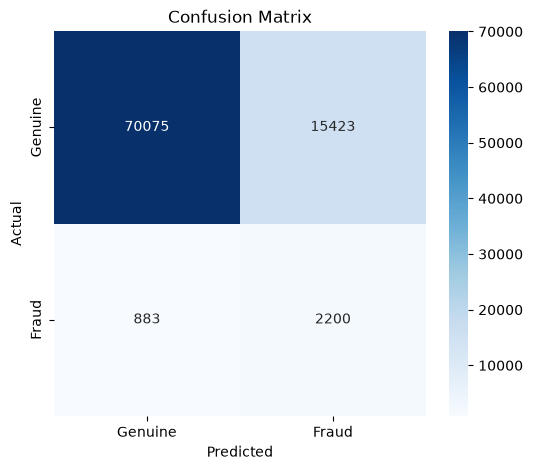

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(
    "\nConfusion Matrix:"
)

print(cm)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Genuine",
        "Fraud"
    ],
    yticklabels=[
        "Genuine",
        "Fraud"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

**Classification report**

In [20]:
report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Genuine",
        "Fraud"
    ],
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

     Genuine       0.99      0.82      0.90     85498
       Fraud       0.12      0.71      0.21      3083

    accuracy                           0.82     88581
   macro avg       0.56      0.77      0.55     88581
weighted avg       0.96      0.82      0.87     88581



**ROC curve**

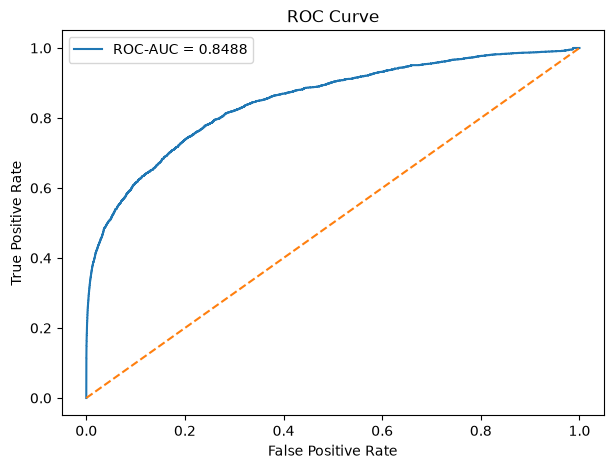

In [21]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

**Precision-Recall curve**

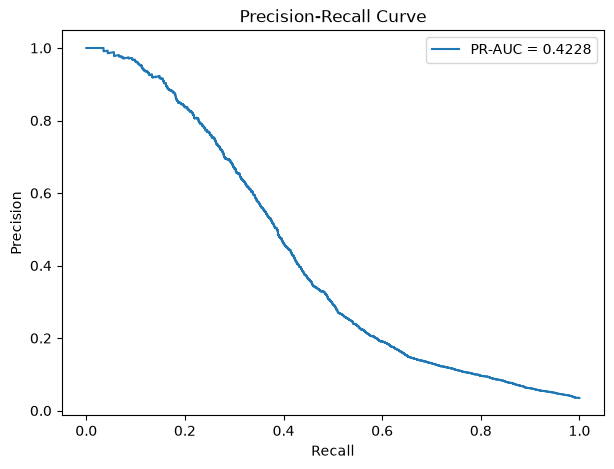

In [22]:
precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        y_prob
    )
)

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {pr_auc:.4f}"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve"
)

plt.legend()

plt.show()

**Learning curves**

In [23]:
history_df = pd.DataFrame(
    history.history
)

**Loss**

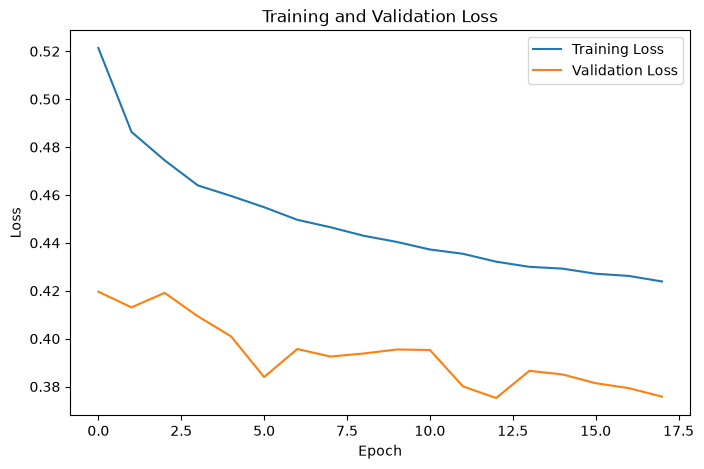

In [24]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.show()

**AUC**

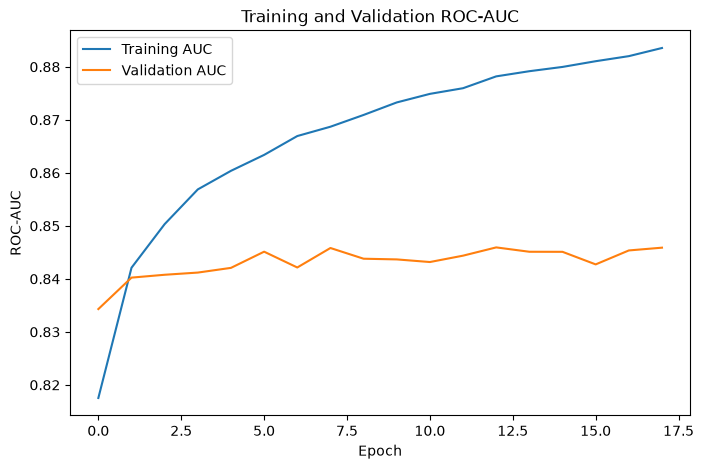

In [25]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["auc"],
    label="Training AUC"
)

plt.plot(
    history_df["val_auc"],
    label="Validation AUC"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "ROC-AUC"
)

plt.title(
    "Training and Validation ROC-AUC"
)

plt.legend()

plt.show()

In [27]:
MODEL_PATH = BASE_PATH / "model"

# Create model folder if it does not exist
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Save MLP model
model.save(
    os.path.join(
        MODEL_PATH,
        "mlp_model.keras"
    )
)

print("MLP model saved successfully.")

MLP model saved successfully.
